In [3]:
import pandas as pd
import numpy as np
np.random.seed(42)
rows = 15000  

def fish_data(n):
    data = []
    species_rules = {
        'TILAPIA': {'t': (24, 32), 'ph': (6.5, 9.0), 'tur': (10, 50),  'ox': (3.0, 7.0), 'am': (0.0, 0.05)},
        'CATFISH': {'t': (22, 30), 'ph': (6.0, 8.5), 'tur': (30, 100), 'ox': (2.5, 6.0), 'am': (0.0, 0.10)},
        'TROUT':   {'t': (10, 18), 'ph': (6.5, 8.0), 'tur': (0, 10),   'ox': (7.0, 10.0),'am': (0.0, 0.01)},
        'CARP':    {'t': (18, 28), 'ph': (7.0, 8.5), 'tur': (10, 40),  'ox': (4.0, 8.0), 'am': (0.0, 0.05)},
        'SALMON':  {'t': (8, 15),  'ph': (6.5, 8.5), 'tur': (0, 5),    'ox': (8.0, 11.0),'am': (0.0, 0.01)},
        'SHRIMP':  {'t': (25, 31), 'ph': (7.5, 8.5), 'tur': (5, 20),   'ox': (5.0, 8.0), 'am': (0.0, 0.02)},
        'ROHU':    {'t': (20, 30), 'ph': (7.0, 8.5), 'tur': (15, 45),  'ox': (4.5, 7.5), 'am': (0.0, 0.05)}
    }
    
    species_list = list(species_rules.keys())
    
    for _ in range(n):
        fish = np.random.choice(species_list)
        r = species_rules[fish]
        
        # Generating randomized data points based on species biological needs
        ph = np.random.uniform(r['ph'][0], r['ph'][1])
        temp = np.random.uniform(r['t'][0], r['t'][1])
        turb = np.random.uniform(r['tur'][0], r['tur'][1])
        oxygen = np.random.uniform(r['ox'][0], r['ox'][1])
        ammonia = np.random.uniform(r['am'][0], r['am'][1])
        
        data.append([
            round(ph, 2), 
            round(temp, 2), 
            round(turb, 2), 
            round(oxygen, 2), 
            round(ammonia, 3), 
            fish
        ])
        
    cols = ['ph', 'temperature', 'turbidity', 'dissolved_oxygen', 'ammonia', 'label']
    return pd.DataFrame(data, columns=cols)


df = fish_data(rows)
df.to_csv('fish_data.csv', index=False)

print(f"Created 'fish_data.csv' with {rows} rows and 6 columns.")
print(f"Species included: {', '.join(df['label'].unique())}")


Created 'fish_data.csv' with 15000 rows and 6 columns.
Species included: ROHU, CATFISH, CARP, SALMON, TILAPIA, SHRIMP, TROUT


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import pickle

data=pd.read_csv("fish_data.csv")
X=data.drop("label",axis=1)
y=data["label"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model=RandomForestClassifier(n_estimators=100)
model.fit(X_train_scaled,y_train)
predictions=model.predict(X_test_scaled)
print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, predictions))
with open("fish_model.pkl","wb") as f:
    pickle.dump(model,f)
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)


--- Model Accuracy ---
Accuracy: 82.40%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        CARP       0.74      0.61      0.67       443
     CATFISH       0.98      0.90      0.94       443
        ROHU       0.56      0.77      0.65       389
      SALMON       0.82      0.94      0.88       442
      SHRIMP       0.96      1.00      0.98       442
     TILAPIA       0.84      0.75      0.79       422
       TROUT       0.93      0.79      0.85       419

    accuracy                           0.82      3000
   macro avg       0.83      0.82      0.82      3000
weighted avg       0.84      0.82      0.83      3000



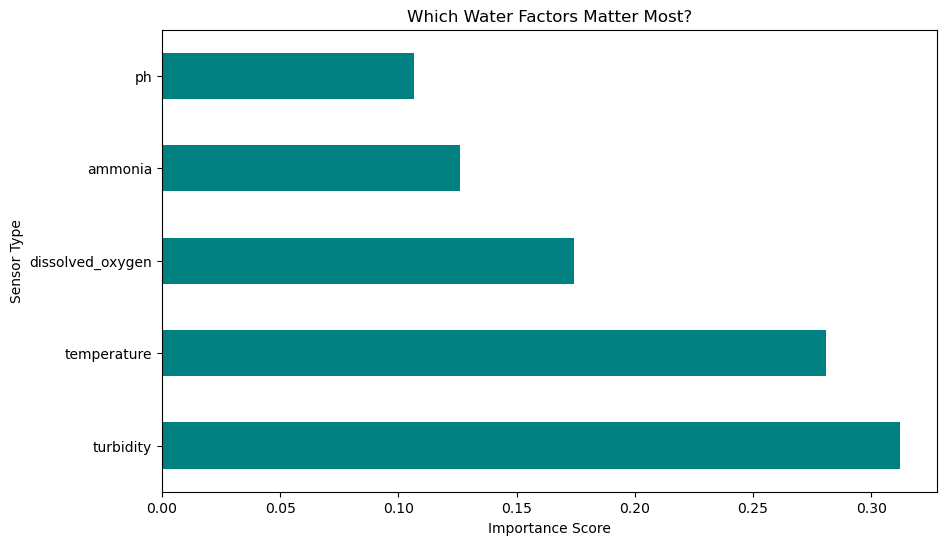

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh', color='teal')
plt.title('Which Water Factors Matter Most?')
plt.xlabel('Importance Score')
plt.ylabel('Sensor Type')
plt.show()